## 1. Data Loading and Preprocessing

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/bank_dataset_v2.csv')

# Standardize the column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

display(df.head())

,row_number,customer_id,first_name,state,gender,age,salary,credit_score,tenure,balance,...,hasloan,hasfd,num_of_products,isactivemember,exited,complain,count_of_complains,satisfaction_score,point_earned,preferred_channel
0,2,MH00002,Nitya,Maharashtra,Female,77,33000.0,538,4,0.00,...,0,0,1,0,1,0,0,5.0,100,Mobile
1,3,KA00003,Vivaan,Karnataka,Male,78,190000.0,531,8,15585.55,...,0,1,2,1,1,0,0,10.0,150,Mobile
2,4,MH00004,Dinesh,Maharashtra,Male,42,330000.0,718,3,155688.22,...,0,1,2,1,0,0,0,10.0,150,Phone
3,5,KA00005,Charvi,Karnataka,Female,29,155000.0,710,7,89415.53,...,0,1,2,1,0,0,0,4.0,90,Branch
4,6,DL00006,Aditi,Delhi,Female,38,111000.0,729,2,36613.80,...,1,0,2,1,0,0,0,4.0,90,Email


## 2. Handle Missing Values

In [27]:
# Impute missing values
df['salary'].fillna(df['salary'].median(), inplace=True)
df['balance'].fillna(0, inplace=True)
df['satisfaction_score'].fillna(df['satisfaction_score'].median(), inplace=True)
df = df.dropna(subset=['gender'])
df['card_type'].fillna(df['card_type'].mode()[0], inplace=True)

# Standardize card type
df["card_type"] = df["card_type"].str.upper().str.strip()

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
row_number            0
customer_id           0
first_name            0
state                 0
gender                0
age                   0
salary                0
credit_score          0
tenure                0
balance               0
hascrcard             0
card_type             0
hasloan               0
hasfd                 0
num_of_products       0
isactivemember        0
exited                0
complain              0
count_of_complains    0
satisfaction_score    0
point_earned          0
preferred_channel     0
dtype: int64


/tmp/ipykernel_2680/3696008783.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['salary'].fillna(df['salary'].median(), inplace=True)
/tmp/ipykernel_2680/3696008783.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

## 3. Outlier Detection and Treatment

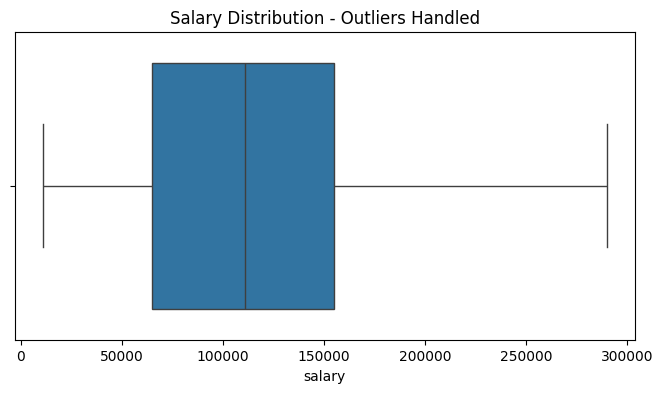

In [28]:
# Identify and cap salary outliers
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)

df["salary"] = np.where(df["salary"] > upper_bound, upper_bound, df["salary"])

plt.figure(figsize=(8, 4))
sns.boxplot(x=df["salary"])
plt.title("Salary Distribution - Outliers Handled")
plt.show()

## 4. Feature Engineering

In [29]:
# Add Debt-to-Income Ratio and Loyalty Score
df["debt_to_income_ratio"] = (df["balance"] + (df["hasloan" ] * df["salary"] * 0.3)) / df["salary"]
df["loyalty_score"] = (df["tenure"] * df["satisfaction_score"]) / (1 + df["count_of_complains"])

# High Complainer flag
df["state_avg_complaints"] = df.groupby("state")["count_of_complains"].transform("mean")
df["high_complainer"] = (df["count_of_complains"] > df["state_avg_complaints"]).astype(int)

display(df.head())

,row_number,customer_id,first_name,state,gender,age,salary,credit_score,tenure,balance,...,exited,complain,count_of_complains,satisfaction_score,point_earned,preferred_channel,debt_to_income_ratio,loyalty_score,state_avg_complaints,high_complainer
0,2,MH00002,Nitya,Maharashtra,Female,77,33000.0,538,4,0.00,...,1,0,0,5.0,100,Mobile,0.000000,20.0,4.235927,0
1,3,KA00003,Vivaan,Karnataka,Male,78,190000.0,531,8,15585.55,...,1,0,0,10.0,150,Mobile,0.082029,80.0,4.297710,0
2,4,MH00004,Dinesh,Maharashtra,Male,42,290000.0,718,3,155688.22,...,0,0,0,10.0,150,Phone,0.536856,30.0,4.235927,0
3,5,KA00005,Charvi,Karnataka,Female,29,155000.0,710,7,89415.53,...,0,0,0,4.0,90,Branch,0.576874,28.0,4.297710,0
4,6,DL00006,Aditi,Delhi,Female,38,111000.0,729,2,36613.80,...,0,0,0,4.0,90,Email,0.629854,8.0,4.317580,0


## 5. Demographic Analysis (v3 Data)

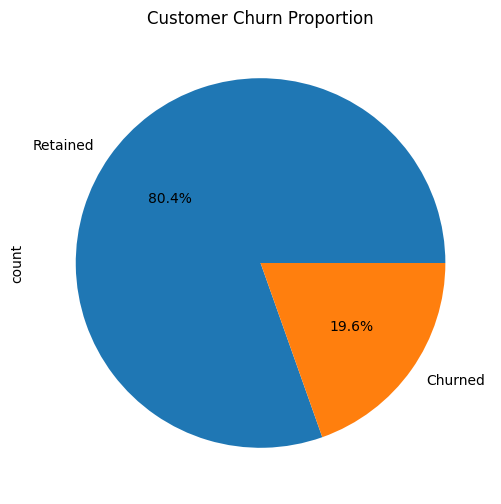

In [30]:
# Load v3 dataset for updated analysis
df = pd.read_csv("https://gitlab.crio.do/me_notebook/me_jupyter_bankattritionanalysis/-/raw/master/bank_dataset_v3.csv",header=0,skiprows=[1])
df["card_type"] = df["card_type"].str.upper().str.strip()
df["churn_status"] = df["exited"].map({0: "Stayed", 1: "Left"})

# Visualize Churn Proportion
plt.figure(figsize=(6, 6))
df['exited'].value_counts().plot(kind='pie', labels=['Retained', 'Churned'], autopct='%1.1f%%')
plt.title('Customer Churn Proportion')
plt.show()

### 5.1 Geographic and Demographic Variation
Exploring how churn varies across different regions and age groups.

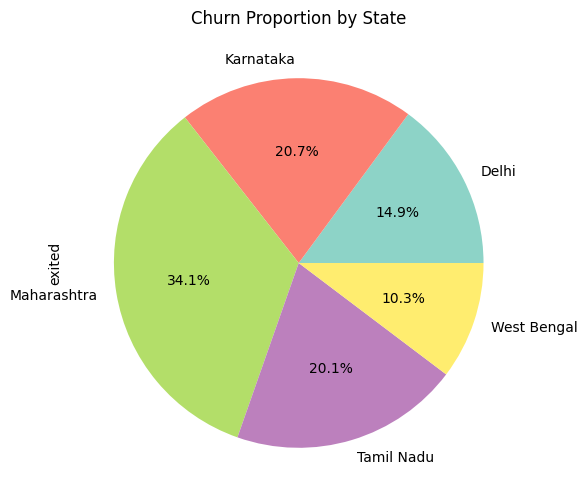

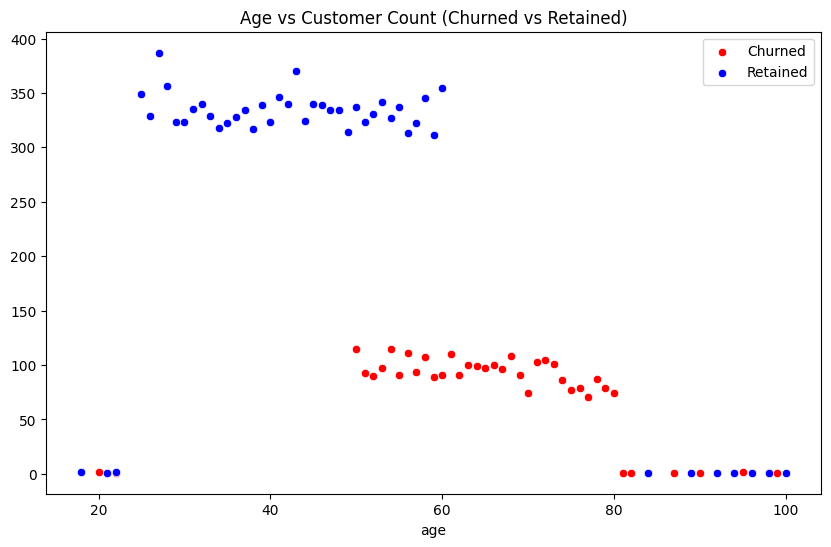

In [32]:
# Churn Proportion by State
plt.figure(figsize=(8, 6))
df.groupby('state')['exited'].sum().plot(kind='pie', autopct='%1.1f%%', cmap='Set3')
plt.title('Churn Proportion by State')
plt.show()

# Age vs Churn Status
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[df['exited']==1].groupby('age').size().index, y=df[df['exited']==1].groupby('age').size().values, color='red', label='Churned')
sns.scatterplot(x=df[df['exited']==0].groupby('age').size().index, y=df[df['exited']==0].groupby('age').size().values, color='blue', label='Retained')
plt.title("Age vs Customer Count (Churned vs Retained)")
plt.legend()
plt.show()

## 5.2 Product Analysis
Analyzing the relationship between bank products (Credit Cards, Loans, FDs) and customer retention.

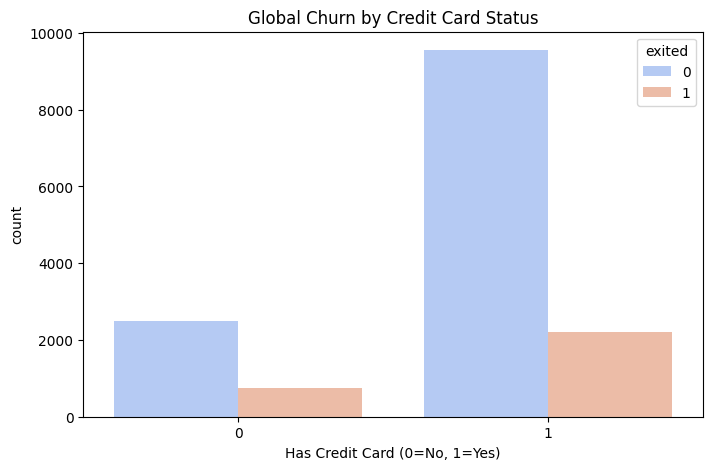

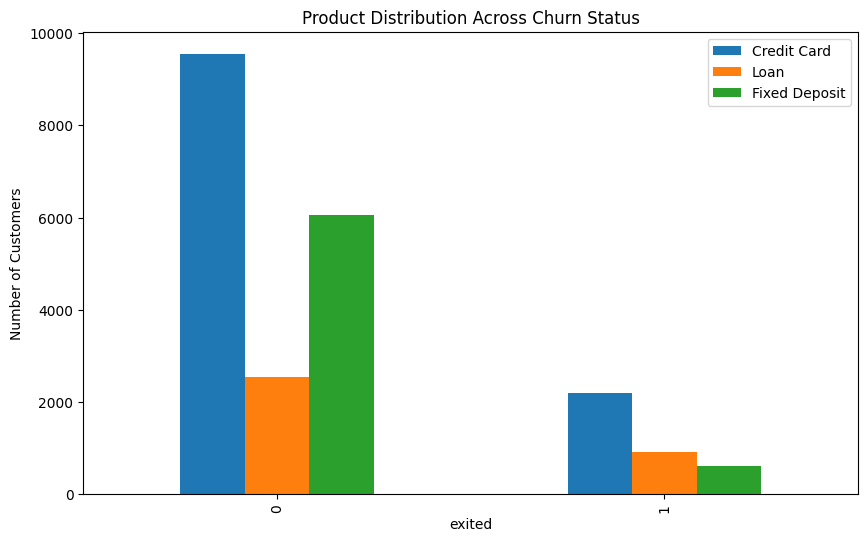

In [33]:
# Credit Card Ownership vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='hascrcard', hue='exited', palette='coolwarm')
plt.title('Global Churn by Credit Card Status')
plt.xlabel('Has Credit Card (0=No, 1=Yes)')
plt.show()

# Product Distribution Comparison
product_dist = pd.DataFrame({
    'Credit Card': df[df['hascrcard'] == 1].groupby('exited').size(),
    'Loan': df[df['hasloan'] == 1].groupby('exited').size(),
    'Fixed Deposit': df[df['hasfd'] == 1].groupby('exited').size()
})
ax = product_dist.plot(kind='bar', figsize=(10, 6))
plt.title('Product Distribution Across Churn Status')
plt.ylabel('Number of Customers')
plt.show()

## 6. Feedback and Financial Analysis

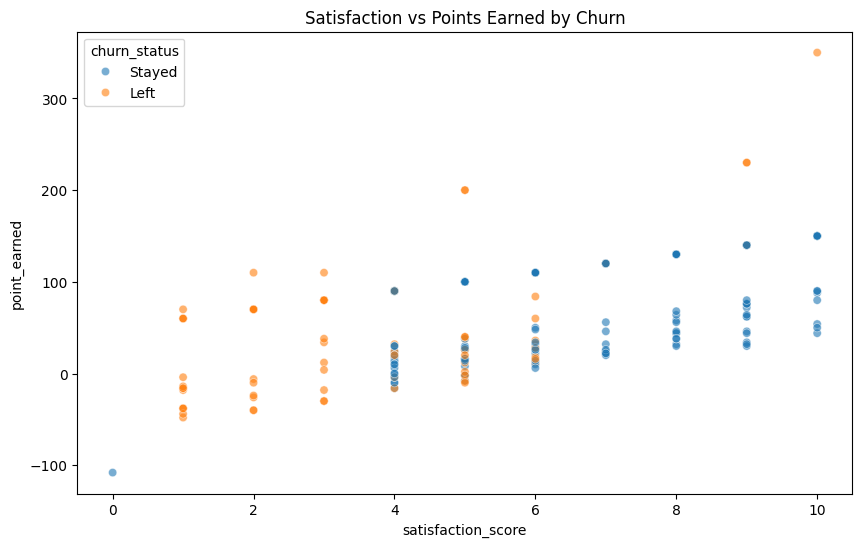

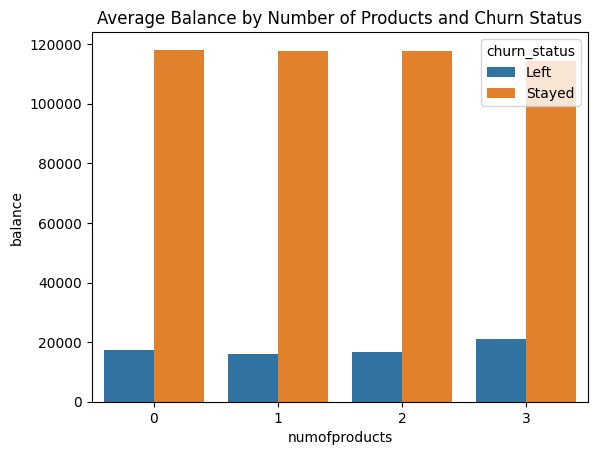

In [31]:
# Satisfaction vs Points Earned
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(500), x='satisfaction_score', y='point_earned', hue='churn_status', alpha=0.6)
plt.title('Satisfaction vs Points Earned by Churn')
plt.show()

# Average Balance by Products
group = df.groupby(['numofproducts', 'churn_status'])['balance'].mean().reset_index()
sns.barplot(x='numofproducts', y='balance', hue='churn_status', data=group)
plt.title('Average Balance by Number of Products and Churn Status')
plt.show()

### 6.1 Feedback & Complaint Analysis
Testing assumptions regarding customer satisfaction and complaint patterns.

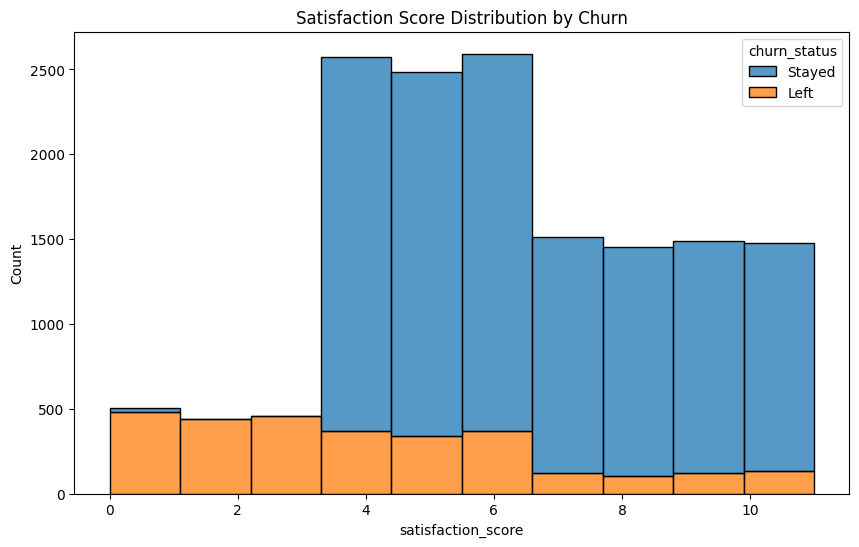

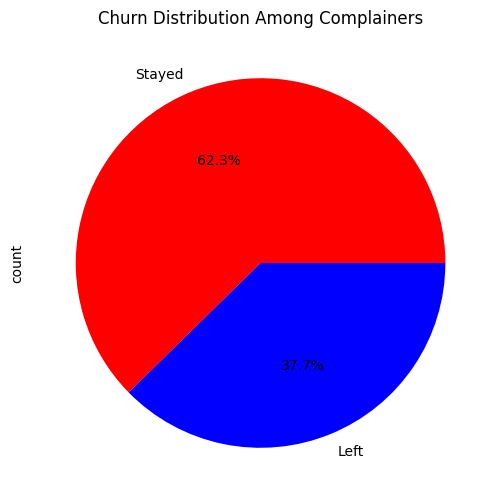

In [34]:
# Satisfaction Score Distribution by Churn Status
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='satisfaction_score', hue='churn_status', multiple='stack', bins=10)
plt.title('Satisfaction Score Distribution by Churn')
plt.show()

# Churn Distribution Among Complainers
complainers = df[df['complain'] == 1]
if not complainers.empty:
    plt.figure(figsize=(6, 6))
    complainers['churn_status'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['red', 'blue'])
    plt.title('Churn Distribution Among Complainers')
    plt.show()

### 6.2 Financial Analysis Deep Dive
Visualizing the relationship between salary, balance, and churn.

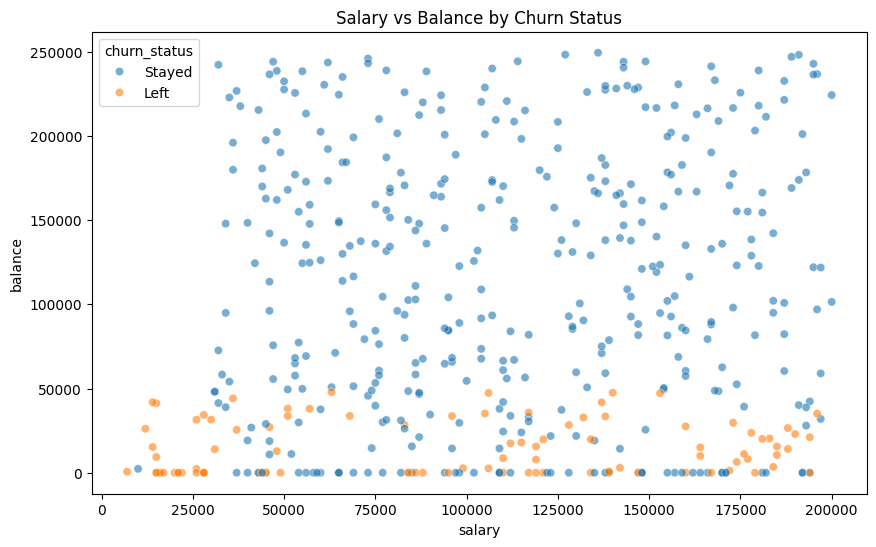

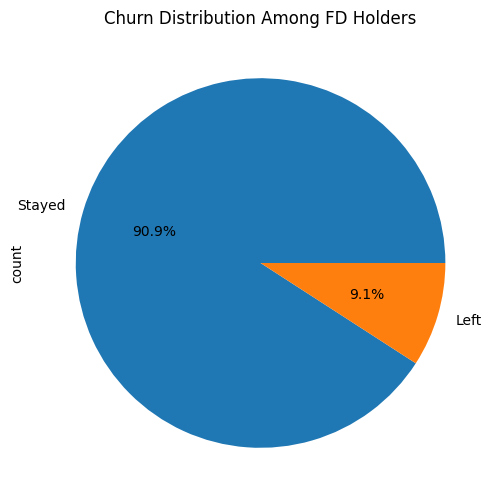

In [35]:
# Salary vs Balance by Churn Status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(n=min(500, len(df))), x='salary', y='balance', hue='churn_status', alpha=0.6)
plt.title('Salary vs Balance by Churn Status')
plt.show()

# Churn Distribution Among FD Holders
fd_holders = df[df['hasfd'] == 1]
if not fd_holders.empty:
    plt.figure(figsize=(6, 6))
    fd_holders['churn_status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title('Churn Distribution Among FD Holders')
    plt.show()